# Aurora Fine-Tuning + Rollout (Config-Driven)

This notebook provides an end-to-end **supervised fine-tuning + rollout** workflow for Aurora,
including **regional/non-global domains** and configurable predictor/target variables.

Workflow stages:
1. Load YAML config
2. Optionally apply local notebook overrides
3. Open and subset train/val/test datasets
4. Build Aurora batches from predictor variables and lead-time targets
5. Configure frozen-backbone or full-model fine-tuning
6. Train + validate + checkpoint (`best.ckpt`, `last.ckpt`)
7. Run rollout from the fine-tuned model
8. Save predictions/diagnostics (NetCDF, history CSV/JSON, manifest)

## Environment / Imports

In [1]:
# Setup: Add project root to Python path
import sys
from pathlib import Path

# Get the project root (parent of finetune directory)
notebook_dir = Path.cwd()
if notebook_dir.name == 'finetune':
    project_root = notebook_dir.parent
else:
    project_root = notebook_dir

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

print(f'Project root: {project_root}')

Project root: /mnt/data3/aurora


In [2]:
from __future__ import annotations

import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
import xarray as xr

import finetune.aurora_finetune_utils as ft
from aurora import (
    Aurora,
    Aurora12hPretrained,
    AuroraAirPollution,
    AuroraHighRes,
    AuroraPretrained,
    AuroraSmallPretrained,
    AuroraWave,
)

## Load YAML Config

In [3]:
# Configuration file path (works from project root or finetune/ directory)
CONFIG_PATH_NAME = 'aurora_finetune_rollout_config.yaml'
if Path(CONFIG_PATH_NAME).exists():
    CONFIG_PATH = Path(CONFIG_PATH_NAME)
elif (Path('finetune') / CONFIG_PATH_NAME).exists():
    CONFIG_PATH = Path('finetune') / CONFIG_PATH_NAME
else:
    raise FileNotFoundError(f'Config file {CONFIG_PATH_NAME} not found')

print(f'Using config: {CONFIG_PATH.resolve()}')

Using config: /mnt/data3/aurora/finetune/aurora_finetune_rollout_config.yaml


## Optional Local Override Cell (Quick Edits)

Use this cell for notebook-local experiments without editing the YAML file.

In [4]:
LOCAL_OVERRIDES = {
    # Example:
    # 'training': {'num_epochs': 1, 'batch_size': 2},
    # 'model': {'backbone_freeze': False, 'trainable_head_only': False},
    # 'rollout': {'rollout_num_steps': 4},
}

In [5]:
cfg = ft.load_config(CONFIG_PATH, overrides=LOCAL_OVERRIDES)
print(json.dumps(cfg, indent=2)[:4000])

{
  "paths": {
    "project_root": "/mnt/data3/aurora/finetune",
    "data_dir": "/mnt/data3/aurora/data",
    "train_data_path": "/mnt/data3/aurora/data/train.nc",
    "val_data_path": "/mnt/data3/aurora/data/train.nc",
    "test_data_path": "/mnt/data3/aurora/data/test.nc",
    "output_dir": "/mnt/data3/aurora/finetune/outputs",
    "checkpoint_dir": "/mnt/data3/aurora/finetune/outputs/checkpoints",
    "pretrained_checkpoint": "",
    "static_data_path": "/mnt/data3/cams/aurora-0.4-air-pollution-static.pickle",
    "optional_resume_checkpoint": ""
  },
  "data": {
    "predictor_variables": [
      {
        "dataset_name": "t2m",
        "aurora_name": "2t",
        "kind": "surf"
      },
      {
        "dataset_name": "u10",
        "aurora_name": "10u",
        "kind": "surf"
      },
      {
        "dataset_name": "v10",
        "aurora_name": "10v",
        "kind": "surf"
      },
      {
        "dataset_name": "msl",
        "aurora_name": "msl",
        "kind": "surf"
   

## Data Loading for Predictors and Targets

In [6]:
train_ds = ft.open_dataset(cfg['paths']['train_data_path'], cfg)
val_ds = ft.open_dataset(cfg['paths']['val_data_path'], cfg)
test_ds = ft.open_dataset(cfg['paths']['test_data_path'], cfg)

# Merge static variables from external pickle (lsm, z, slt) into each dataset.
static_path = cfg['paths'].get('static_data_path', '')
if static_path:
    train_ds = ft.merge_external_static_vars(train_ds, static_path, cfg)
    val_ds = ft.merge_external_static_vars(val_ds, static_path, cfg)
    test_ds = ft.merge_external_static_vars(test_ds, static_path, cfg)
    print(f'Merged static vars from: {static_path}')

resolved_specs = ft.resolve_variable_specs(train_ds, cfg)

print('Train:', train_ds.sizes)
print('Val:  ', val_ds.sizes)
print('Test: ', test_ds.sizes)
print('Predictors:', [f"{s.dataset_name}->{s.aurora_name} ({s.kind})" for s in resolved_specs.predictors])
print('Targets:   ', [f"{s.dataset_name}->{s.aurora_name} ({s.kind})" for s in resolved_specs.targets])
print('Static:    ', [f"{s.dataset_name}->{s.aurora_name} ({s.kind})" for s in resolved_specs.static])

Merged static vars from: /mnt/data3/cams/aurora-0.4-air-pollution-static.pickle
Train: Frozen({'time': 112, 'latitude': 63, 'longitude': 188, 'level': 13})
Val:   Frozen({'time': 112, 'latitude': 63, 'longitude': 188, 'level': 13})
Test:  Frozen({'time': 6, 'latitude': 63, 'longitude': 188, 'level': 13})
Predictors: ['t2m->2t (surf)', 'u10->10u (surf)', 'v10->10v (surf)', 'msl->msl (surf)', 'tcno2->tcno2 (surf)', 'z->z (atmos)', 'u->u (atmos)', 'v->v (atmos)', 't->t (atmos)', 'q->q (atmos)', 'no2->no2 (atmos)']
Targets:    ['no2->no2 (atmos)', 'tcno2->tcno2 (surf)']
Static:     ['lsm->lsm (static)', 'z_static->z (static)', 'slt->slt (static)', 'static_ammonia->static_ammonia (static)', 'static_ammonia_log->static_ammonia_log (static)', 'static_co->static_co (static)', 'static_co_log->static_co_log (static)', 'static_nox->static_nox (static)', 'static_nox_log->static_nox_log (static)', 'static_so2->static_so2 (static)', 'static_so2_log->static_so2_log (static)']


## Regional Domain Handling

In [7]:
lat_dim = cfg['data'].get('lat_dim', 'latitude')
lon_dim = cfg['data'].get('lon_dim', 'longitude')

print('Domain type:', cfg['data'].get('domain_type', 'global'))
print('Latitude range:', float(train_ds[lat_dim].values.max()), 'to', float(train_ds[lat_dim].values.min()))
print('Longitude range:', float(train_ds[lon_dim].values.min()), 'to', float(train_ds[lon_dim].values.max()))
print('Grid shape:', train_ds.sizes[lat_dim], 'x', train_ds.sizes[lon_dim])

Domain type: regional
Latitude range: 49.99999999999969 to 25.199999999999775
Longitude range: 235.20000000000226 to 309.9999999999995
Grid shape: 63 x 188


## Batch Construction for Aurora


In [8]:
train_samples = ft.build_training_samples(train_ds, cfg, split_name='train')
val_samples = ft.build_training_samples(val_ds, cfg, split_name='val')

# Test set has only 2 time steps (enough for rollout start, not for supervised samples).
# Build a rollout-start sample manually: history = [0, 1], no targets needed.
input_steps = int(cfg['data'].get('input_time_steps', 2))
test_samples = [{
    'anchor_index': input_steps - 1,
    'history_indices': list(range(input_steps)),
    'target_indices': {},
}]

print('Num train samples:', len(train_samples))
print('Num val samples:  ', len(val_samples))
print('Num test samples (rollout start):', len(test_samples))

quick_idx = int(cfg.get('notebook', {}).get('quicklook_sample_index', 0))
quick_idx = max(0, min(quick_idx, len(train_samples) - 1))
quick_batch = ft.build_aurora_batch(train_ds, train_samples[quick_idx], cfg, resolved_specs)

print('Quick batch spatial shape:', quick_batch.spatial_shape)
print('Quick batch time:', quick_batch.metadata.time)
print('Quick batch levels:', quick_batch.metadata.atmos_levels)

Num train samples: 109
Num val samples:   109
Num test samples (rollout start): 1
Quick batch spatial shape: torch.Size([63, 186])
Quick batch time: (datetime.datetime(2026, 2, 1, 12, 0),)
Quick batch levels: (50.0, 100.0, 150.0, 200.0, 250.0, 300.0, 400.0, 500.0, 600.0, 700.0, 850.0, 925.0, 1000.0)


## Model Initialization

In [9]:
# ── Distributed Training ──────────────────────────────────────────────
# Launch training across all idle GPUs using the distributed script.
# This avoids OOM by: (1) storing params in bf16, and (2) sharding data
# across multiple GPUs with manual gradient all-reduce.

import subprocess, sys, gc, shutil, threading

# Release any GPU memory held by this notebook kernel before launching.
if torch.cuda.is_available():
    gc.collect()
    torch.cuda.empty_cache()

# Locate the distributed script relative to this notebook.
_nb_dir = Path('.').resolve()
for _candidate in [
    _nb_dir / 'aurora_finetune_distributed.py',
    _nb_dir / 'finetune' / 'aurora_finetune_distributed.py',
]:
    if _candidate.exists():
        dist_script = str(_candidate)
        break
else:
    raise FileNotFoundError('Cannot find aurora_finetune_distributed.py')

# Resolve the Python executable: prefer the Aurora conda env,
# fall back to sys.executable if not found.
_aurora_py = '/mnt/data2/kyo/mamba/envs/Aurora/bin/python'
if not Path(_aurora_py).exists():
    _aurora_py = sys.executable
cmd = [_aurora_py, dist_script]
# Optionally specify GPUs: cmd += ['--gpus', '5,6,7']

print(f'Launching: {" ".join(cmd)}')
print('=' * 60, flush=True)

# Stream stdout/stderr live so progress bars are visible.
proc = subprocess.Popen(
    cmd,
    stdout=subprocess.PIPE,
    stderr=subprocess.PIPE,
    text=True,
    bufsize=1,  # line-buffered
)

def _stream_stderr(p):
    for line in p.stderr:
        print(line, end='', flush=True)

stderr_thread = threading.Thread(target=_stream_stderr, args=(proc,), daemon=True)
stderr_thread.start()

for line in proc.stdout:
    print(line, end='', flush=True)

stderr_thread.join(timeout=5)
rc = proc.wait()

print('=' * 60)
if rc != 0:
    raise RuntimeError(
        f'Distributed training failed (exit {rc}). '
        f'If GPUs are occupied by stale processes, restart the notebook kernel first.'
    )
print('Distributed training completed successfully.')

Launching: /mnt/data2/kyo/mamba/envs/Aurora/bin/python /mnt/data3/aurora/finetune/aurora_finetune_distributed.py
Launching on 2 GPU(s): [2, 7]

*****************************************
Setting OMP_NUM_THREADS environment variable for each process to be 1 in default, to avoid your system being overloaded, please further tune the variable for optimal performance in your application as needed. 
*****************************************
Norm stats: {'no2': {'mean': [7.369182486449688e-10, 1.678906319524387e-10, 2.0493609587113326e-10, 1.7596761547888917e-10, 8.466415069019462e-11, 5.4907672158988063e-11, 4.789789745385242e-11, 4.901018479941399e-11, 5.622681140127206e-11, 8.303963766609357e-11, 3.576303142516224e-10, 8.263268402863844e-10, 1.7718437828051492e-09], 'std': [3.696328243485425e-10, 1.0829301344550402e-10, 1.833735802092562e-10, 1.6621590215315507e-10, 1.208266681151926e-10, 8.433595488632761e-11, 5.935664459943979e-11, 5.5900728490598794e-11, 7.451505384947765e-11, 1.33744321

## Freeze / Unfreeze Configuration

In [10]:
# ── Load results from distributed training ─────────────────────────
import subprocess as _sp

model_cfg = cfg['model']
train_cfg = cfg['training']
checkpoint_dir = Path(cfg['paths']['checkpoint_dir'])
output_dir = Path(cfg['paths']['output_dir'])
best_ckpt_path = checkpoint_dir / 'best.ckpt'
last_ckpt_path = checkpoint_dir / 'last.ckpt'

# Pick the idle GPU with the most free memory using nvidia-smi
# (avoids creating CUDA contexts on busy GPUs which itself can OOM).
def _pick_best_gpu():
    try:
        out = _sp.check_output(
            ['nvidia-smi', '--query-gpu=index,memory.free',
             '--format=csv,noheader,nounits'], text=True)
    except Exception:
        return 0
    best_idx, best_free = 0, 0
    for line in out.strip().splitlines():
        parts = line.split(',')
        idx, free = int(parts[0]), float(parts[1])
        if free > best_free:
            best_idx, best_free = idx, free
    print(f'Auto-selected GPU {best_idx} ({best_free/1024:.1f} GB free)')
    return best_idx

device = torch.device(f'cuda:{_pick_best_gpu()}')

# Reconstruct model (lightweight — on CPU first)
variant = str(model_cfg.get('model_variant', 'aurora_pretrained')).lower()
MODEL_REGISTRY = {
    'aurora': Aurora, 'aurora_pretrained': AuroraPretrained,
    'aurora_small_pretrained': AuroraSmallPretrained,
    'aurora_12h_pretrained': Aurora12hPretrained,
    'aurora_highres': AuroraHighRes, 'aurora_air_pollution': AuroraAirPollution,
    'aurora_wave': AuroraWave,
}
model_var_cfg = ft.derive_model_variable_config(resolved_specs, cfg)
model_kwargs = dict(model_cfg.get('model_kwargs', {}))
if 'patch_size' in model_cfg and 'patch_size' not in model_kwargs:
    model_kwargs['patch_size'] = int(model_cfg['patch_size'])
model_kwargs['autocast'] = False

model = MODEL_REGISTRY[variant](
    surf_vars=model_var_cfg['surf_vars'],
    static_vars=model_var_cfg['static_vars'],
    atmos_vars=model_var_cfg['atmos_vars'],
    **model_kwargs,
)

# Load best checkpoint
ckpt_to_load = best_ckpt_path if best_ckpt_path.exists() else last_ckpt_path
if ckpt_to_load.exists():
    state = torch.load(str(ckpt_to_load), map_location='cpu', weights_only=False)
    model.load_state_dict(state['model_state_dict'])
    print(f'Loaded checkpoint: {ckpt_to_load}')
    print(f'  epoch={state.get("epoch")}, step={state.get("global_step")}, '
          f'best_val_loss={state.get("best_val_loss", "n/a")}')
else:
    print('WARNING: No checkpoint found — using untrained model')

mixed_precision_mode = str(model_cfg.get('mixed_precision', 'none')).lower()
use_bf16 = mixed_precision_mode in {'bf16', 'bfloat16'}
if use_bf16:
    model = model.to(dtype=torch.bfloat16)
model = model.to(device)
model.eval()

param_summary = ft.configure_trainable_parameters(model, cfg)
print(f'Model on {device}, params: {json.dumps(param_summary)}')


Auto-selected GPU 2 (22.0 GB free)
Loaded checkpoint: /mnt/data3/aurora/finetune/outputs/checkpoints/best.ckpt
  epoch=9, step=280, best_val_loss=0.4205610752105713
Model on cuda:2, params: {"total_parameters": 1271061904, "trainable_parameters": 17686416, "frozen_parameters": 1253375488}


## Fine-Tuning Loop

In [11]:
# ── Load training history ──────────────────────────────────────────
history_path = output_dir / 'training_history.json'
if history_path.exists():
    history = json.loads(history_path.read_text())
    print(f'Loaded {len(history)} history rows')
else:
    # Try CSV fallback
    history_csv = output_dir / 'training_history.csv'
    if history_csv.exists():
        import csv
        with open(history_csv) as f:
            history = list(csv.DictReader(f))
            for h in history:
                for k in h:
                    try: h[k] = float(h[k])
                    except (ValueError, TypeError): pass
        print(f'Loaded {len(history)} history rows from CSV')
    else:
        history = []
        print('No training history file found')


Loaded 10 history rows


## Validation


In [12]:
if history:
    print('Best validation loss:', float(np.nanmin([h['val_loss'] for h in history])))
    print('Final epoch record:', history[-1])
else:
    print('No history rows were recorded.')

Best validation loss: 0.4205610752105713
Final epoch record: {'epoch': 9, 'global_step': 280, 'train_loss': 0.4279043972492218, 'val_loss': 0.4205610752105713, 'lr': 0.0003}


## Loss vs Epochs Plot

✓ Saved loss plot: /mnt/data3/aurora/finetune/outputs/loss_vs_epochs.png


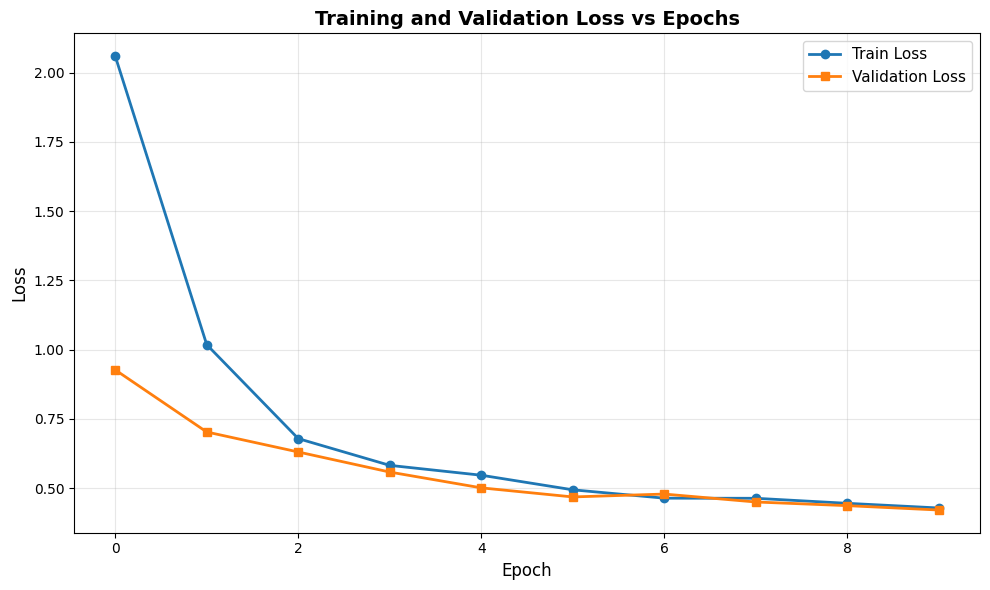

In [13]:
# Plot Training and Validation Loss
if history:
    epochs = [h['epoch'] for h in history]
    train_losses = [h['train_loss'] for h in history]
    val_losses = [h['val_loss'] for h in history]
    
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.plot(epochs, train_losses, 'o-', label='Train Loss', linewidth=2, markersize=6)
    ax.plot(epochs, val_losses, 's-', label='Validation Loss', linewidth=2, markersize=6)
    ax.set_xlabel('Epoch', fontsize=12)
    ax.set_ylabel('Loss', fontsize=12)
    ax.set_title('Training and Validation Loss vs Epochs', fontsize=14, fontweight='bold')
    ax.legend(fontsize=11)
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    
    loss_plot_path = output_dir / 'loss_vs_epochs.png'
    fig.savefig(loss_plot_path, dpi=150)
    print(f'✓ Saved loss plot: {loss_plot_path}')
    plt.show()
else:
    print('No training history to plot.')

## Checkpoint Saving


In [14]:
print('Best checkpoint:', best_ckpt_path, '| exists:', best_ckpt_path.exists())
print('Last checkpoint:', last_ckpt_path, '| exists:', last_ckpt_path.exists())


Best checkpoint: /mnt/data3/aurora/finetune/outputs/checkpoints/best.ckpt | exists: True
Last checkpoint: /mnt/data3/aurora/finetune/outputs/checkpoints/last.ckpt | exists: True


## Rollout Inference from Fine-Tuned Model

In [15]:
# -- Inference commented out -- use aurora_inference_rollout.ipynb instead --
# rollout_cfg = cfg['rollout']
# predictions = []
#
# if bool(rollout_cfg.get('run_rollout_after_training', True)):
#     if not test_samples:
#         raise ValueError('No test samples available for rollout.')
#
#     rollout_idx = int(cfg.get('notebook', {}).get('quicklook_sample_index', 0))
#     rollout_idx = max(0, min(rollout_idx, len(test_samples) - 1))
#
#     model.eval()
#     predictions = ft.run_rollout(
#         model=model,
#         ds=test_ds,
#         start_sample=test_samples[rollout_idx],
#         config=cfg,
#         resolved_specs=resolved_specs,
#         device=device,
#     )
#
# # Convert bf16 predictions to fp32 for numpy/netCDF compatibility.
# predictions = [p.type(torch.float32) for p in predictions]
# print('Rollout prediction steps:', len(predictions))

## Output Writing and Simple Plots / Diagnostics

In [16]:
# -- Inference output/plots commented out -- use aurora_inference_rollout.ipynb instead --
# artifacts = {
#     'best_checkpoint': str(best_ckpt_path.resolve()) if best_ckpt_path.exists() else '',
#     'last_checkpoint': str(last_ckpt_path.resolve()) if last_ckpt_path.exists() else '',
# }
#
# rollout_cfg = cfg['rollout']
# output_dir = Path(cfg['paths']['output_dir'])
# rollout_path = output_dir / 'rollout_predictions.nc'
#
# rollout_ds = None
# if predictions and bool(rollout_cfg.get('save_predictions_to_netcdf', True)):
#     rollout_ds = ft.save_predictions(
#         predictions,
#         rollout_path,
#         save_netcdf=True,
#         resolved_specs=resolved_specs,
#     )
#     artifacts['rollout_netcdf'] = str(rollout_path.resolve())
#     print('Saved rollout NetCDF:', rollout_path)
#
# plot_vars = cfg.get('notebook', {}).get('plot_variables', [])
# if rollout_ds is not None and plot_vars and bool(rollout_cfg.get('save_plots', True)):
#     var = str(plot_vars[0])
#
#     fig, ax = plt.subplots(figsize=(8, 4))
#     if var in rollout_ds:
#         da = rollout_ds[var]
#         if 'level' in da.dims:
#             image = da.isel(step=0, batch=0, level=0)
#             title = f'{var} | step=0 | level=0'
#         else:
#             image = da.isel(step=0, batch=0)
#             title = f'{var} | step=0'
#     else:
#         image = None
#         title = f'Variable {var!r} not found in rollout outputs.'
#
#     if image is not None:
#         mesh = ax.imshow(image.values, origin='upper')
#         fig.colorbar(mesh, ax=ax, shrink=0.8)
#         ax.set_title(title)
#         ax.set_xlabel('longitude index')
#         ax.set_ylabel('latitude index')
#
#         fig_path = output_dir / f'quicklook_{var}.png'
#         fig.tight_layout()
#         fig.savefig(fig_path, dpi=150)
#         artifacts['quicklook_figure'] = str(fig_path.resolve())
#         print('Saved quicklook figure:', fig_path)
#     else:
#         ax.text(0.5, 0.5, title, ha='center', va='center')
#         ax.axis('off')

manifest_path = ft.write_run_manifest(
    cfg,
    output_dir,
    extras={
        'parameter_summary': param_summary,
        'num_train_samples': len(train_samples),
        'num_val_samples': len(val_samples),
        'num_test_samples': len(test_samples),
    },
)

print('Run manifest:', manifest_path)

Run manifest: /mnt/data3/aurora/finetune/outputs/run_manifest.json
